In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Cargar datos limpios
df = pd.read_csv(r"C:\Users\chris\credit-churn-analysis\data_limpia.csv")

print(f"✅ Datos cargados: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"\nColumnas categóricas: {df.select_dtypes('object').columns.tolist()}")

✅ Datos cargados: 10,127 filas | 21 columnas

Columnas categóricas: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Age_Group']


C:\Users\chris\AppData\Local\Temp\ipykernel_20824\4040037903.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"\nColumnas categóricas: {df.select_dtypes('object').columns.tolist()}")


In [2]:
# Eliminar columna auxiliar
df = df.drop(columns=['Age_Group'])

# Convertir columnas categóricas a números
encoder = LabelEncoder()
categorical_cols = ['Gender', 'Education_Level', 'Marital_Status', 
                    'Income_Category', 'Card_Category']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("✅ Encoding completado")
print(f"Columnas categóricas restantes: {df.select_dtypes('object').columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

✅ Encoding completado
Columnas categóricas restantes: []

Primeras filas:


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [3]:
# Separar variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ División completada")
print(f"   Entrenamiento: {X_train.shape[0]:,} clientes")
print(f"   Prueba:        {X_test.shape[0]:,} clientes")
print(f"\nTasa de churn en entrenamiento: {y_train.mean():.1%}")
print(f"Tasa de churn en prueba:        {y_test.mean():.1%}")

✅ División completada
   Entrenamiento: 8,101 clientes
   Prueba:        2,026 clientes

Tasa de churn en entrenamiento: 16.1%
Tasa de churn en prueba:        16.0%


In [4]:
# Entrenar Regresión Logística
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# Evaluar en datos de prueba
y_pred_lr = modelo_lr.predict(X_test)
auc_lr = roc_auc_score(y_test, modelo_lr.predict_proba(X_test)[:, 1])

print("✅ Regresión Logística")
print(f"   AUC-ROC: {auc_lr:.3f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Se quedó', 'Se fue']))

✅ Regresión Logística
   AUC-ROC: 0.894

              precision    recall  f1-score   support

    Se quedó       0.91      0.97      0.94      1701
      Se fue       0.75      0.47      0.58       325

    accuracy                           0.89      2026
   macro avg       0.83      0.72      0.76      2026
weighted avg       0.88      0.89      0.88      2026



C:\Users\chris\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# Entrenar Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# Evaluar
y_pred_rf = modelo_rf.predict(X_test)
auc_rf = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:, 1])

print("✅ Random Forest")
print(f"   AUC-ROC: {auc_rf:.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Se quedó', 'Se fue']))

✅ Random Forest
   AUC-ROC: 0.985

              precision    recall  f1-score   support

    Se quedó       0.96      0.99      0.98      1701
      Se fue       0.94      0.81      0.87       325

    accuracy                           0.96      2026
   macro avg       0.95      0.90      0.92      2026
weighted avg       0.96      0.96      0.96      2026



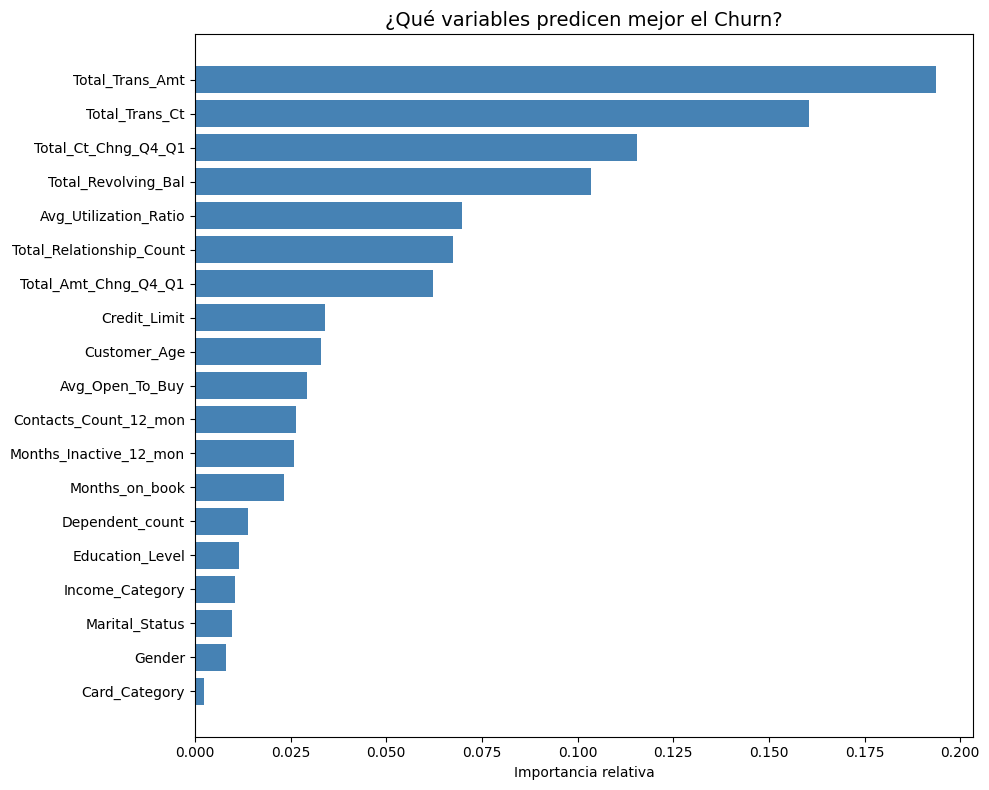

In [6]:
# Importancia de variables en Random Forest
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importances['Variable'], importances['Importancia'], color='steelblue')
plt.title('¿Qué variables predicen mejor el Churn?', fontsize=14)
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

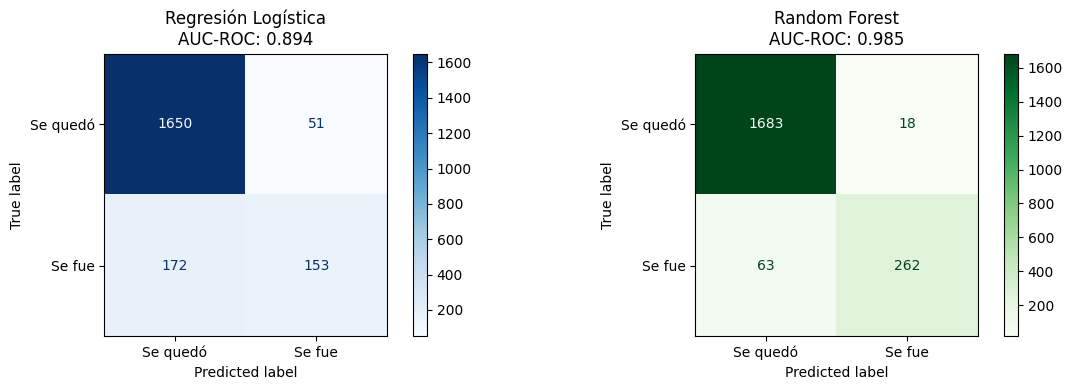

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión - Regresión Logística
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Se quedó', 'Se fue'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Regresión Logística\nAUC-ROC: {auc_lr:.3f}')

# Matriz de confusión - Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Se quedó', 'Se fue'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest\nAUC-ROC: {auc_rf:.3f}')

plt.tight_layout()
plt.show()